In [1]:
import shap
import lightgbm as lgb
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir("/content/drive/MyDrive/MajorProject/Baseline_LGBM"))

['lgbm_model.txt', 'y_pred.npy', 'y_pred_probs.npy', 'label_encoder.pkl', 'X_test.csv', 'y_test.csv', 'feature_names.pkl']


## Load everything

In [4]:
LOAD_DIR = "/content/drive/MyDrive/MajorProject/ModelB_LGBM"

# Load baseline model
model = lgb.Booster(model_file=f"{LOAD_DIR}/lgbm_augmented_model.txt")

# Load test data
X_test = pd.read_csv(f"{LOAD_DIR}/X_test_aug.csv")

# Load label encoder FIRST
with open(f"{LOAD_DIR}/label_encoder_aug.pkl", "rb") as f:
    le = pickle.load(f)

# Load labels and encode them properly
y_test_raw = pd.read_csv(f"{LOAD_DIR}/y_test_aug.csv")["label"]
y_test = le.transform(y_test_raw)   # 🔥 FIX

print("✅ Loaded model B and data")

✅ Loaded model B and data


## SHAP explainer

In [5]:
explainer = shap.TreeExplainer(model)

# Target minority classes
TARGET_CLASSES = [
    "Backdoor_Malware",
    "Recon-PingSweep",
    "SqlInjection",
    "XSS",
    "Uploading_Attack"
]

# filter dataset
target_mask = np.isin(y_test_raw, TARGET_CLASSES)

# convert y_test to pandas Series to preserve index
y_test_series = pd.Series(y_test, index=X_test.index)

# filter dataset (index preserved)
X_focus = X_test[target_mask]
y_focus = y_test_series[target_mask]

# sample
X_sample = X_focus.sample(1000, random_state=42)
y_sample = y_focus.loc[X_sample.index]

# compute SHAP
shap_values = explainer.shap_values(X_sample)

print("✅ Using focused minority-class sample")

✅ Using focused minority-class sample


### SHAP summary (all classes)

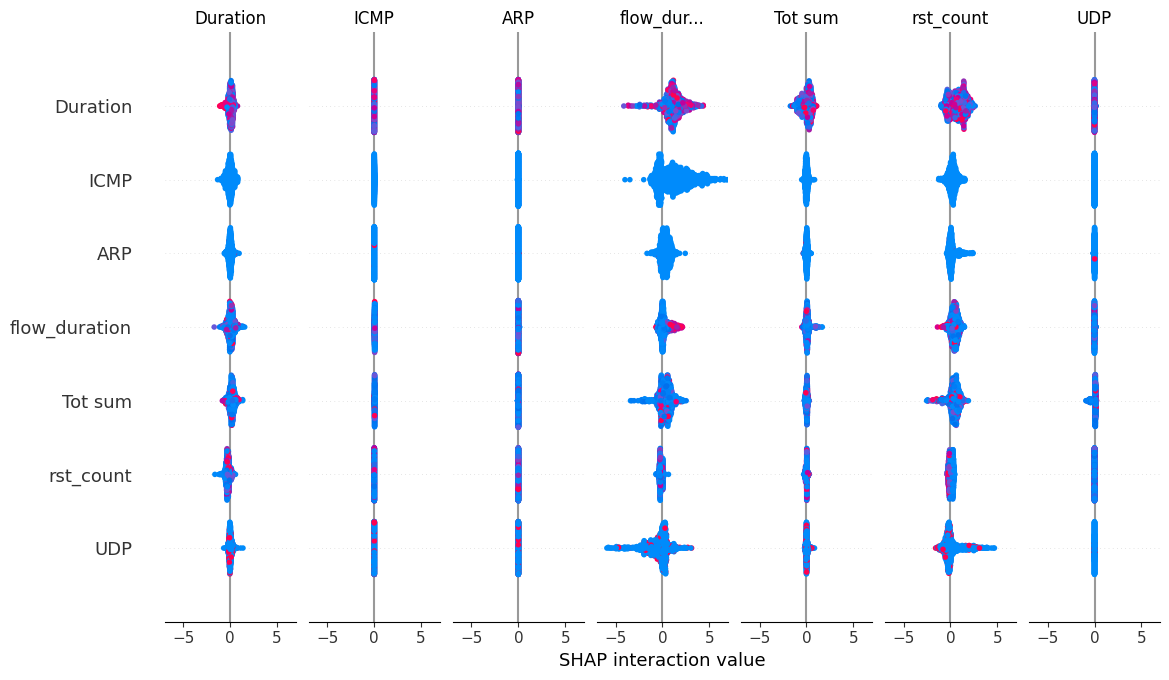

In [6]:
shap.summary_plot(shap_values, X_sample)

## 2. Class-wise SHAP

In [7]:
def plot_class_shap(class_name):
    class_idx = list(le.classes_).index(class_name)

    if isinstance(shap_values, list):
        # old format (list of arrays)
        shap.summary_plot(shap_values[class_idx], X_sample)
    else:
        # new format (3D array)
        shap.summary_plot(shap_values[:, :, class_idx], X_sample)

### Strong class (Example: DDoS)

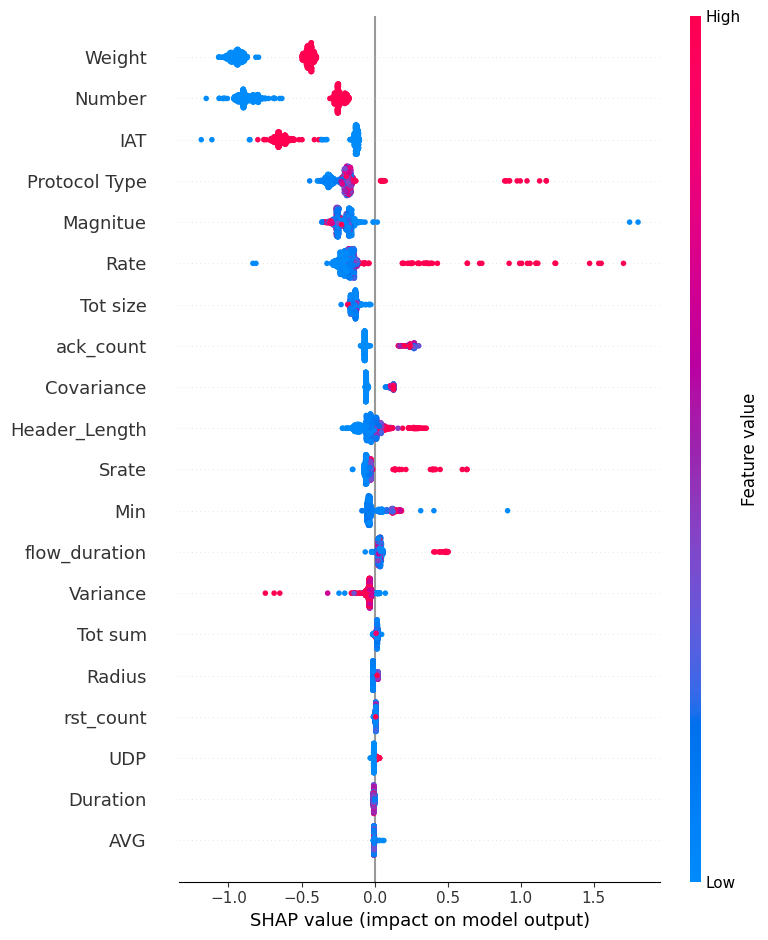

In [8]:
plot_class_shap("DDoS-UDP_Flood")

### Weak class (Example: XSS)

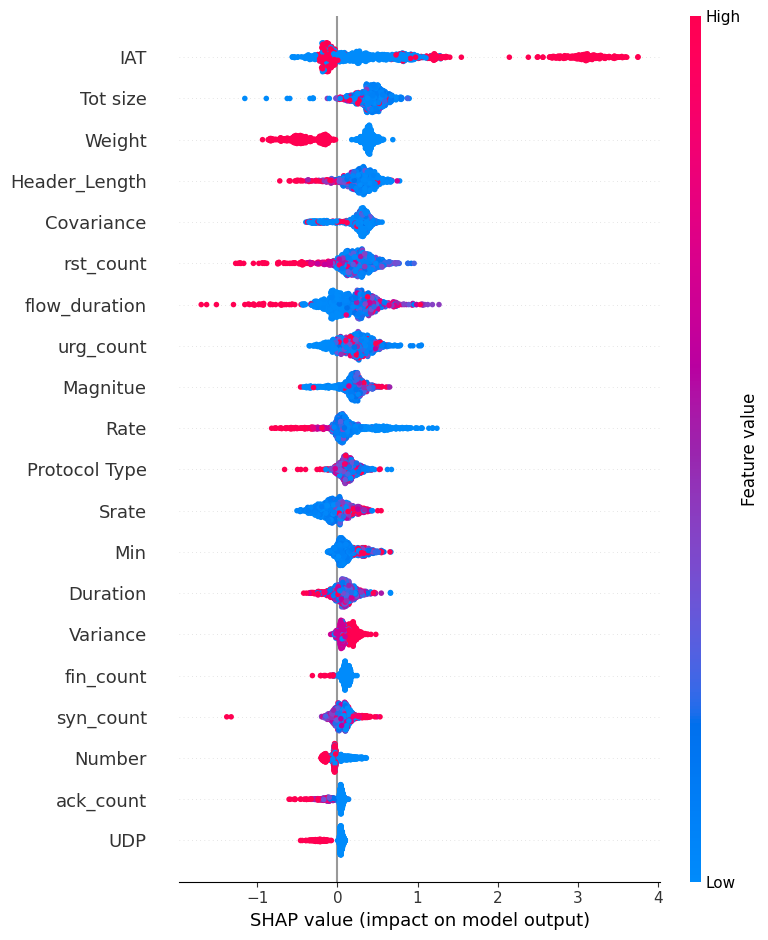

In [9]:
plot_class_shap("XSS")

### Another weak class (Example: Uploading attack)

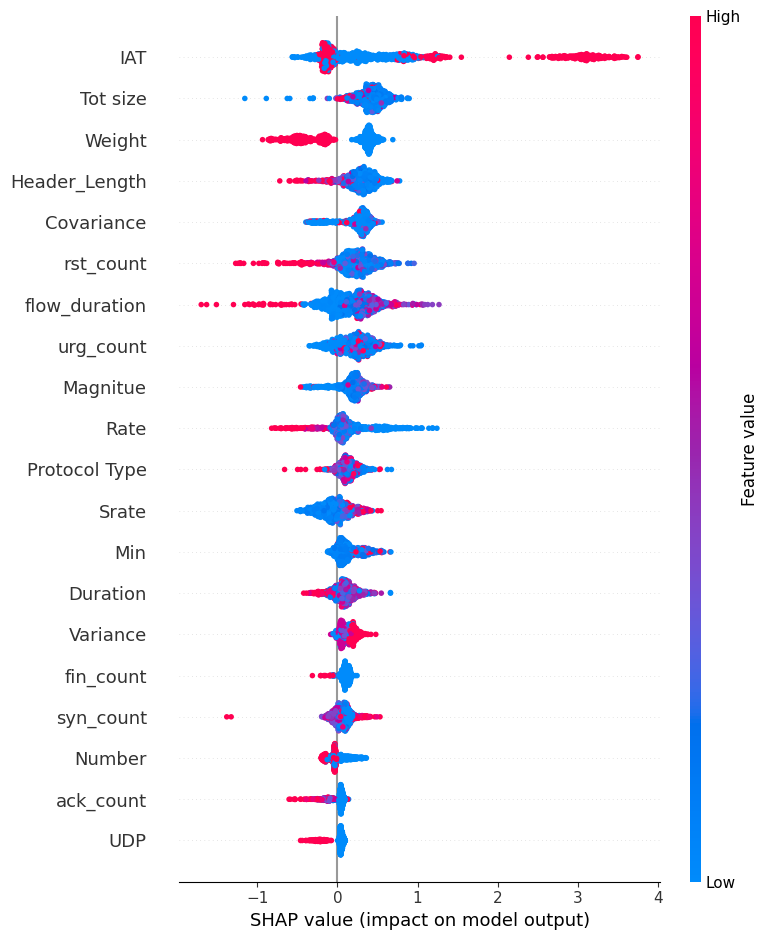

In [10]:
plot_class_shap("XSS")

## 3. Feature importance (SHAP based)

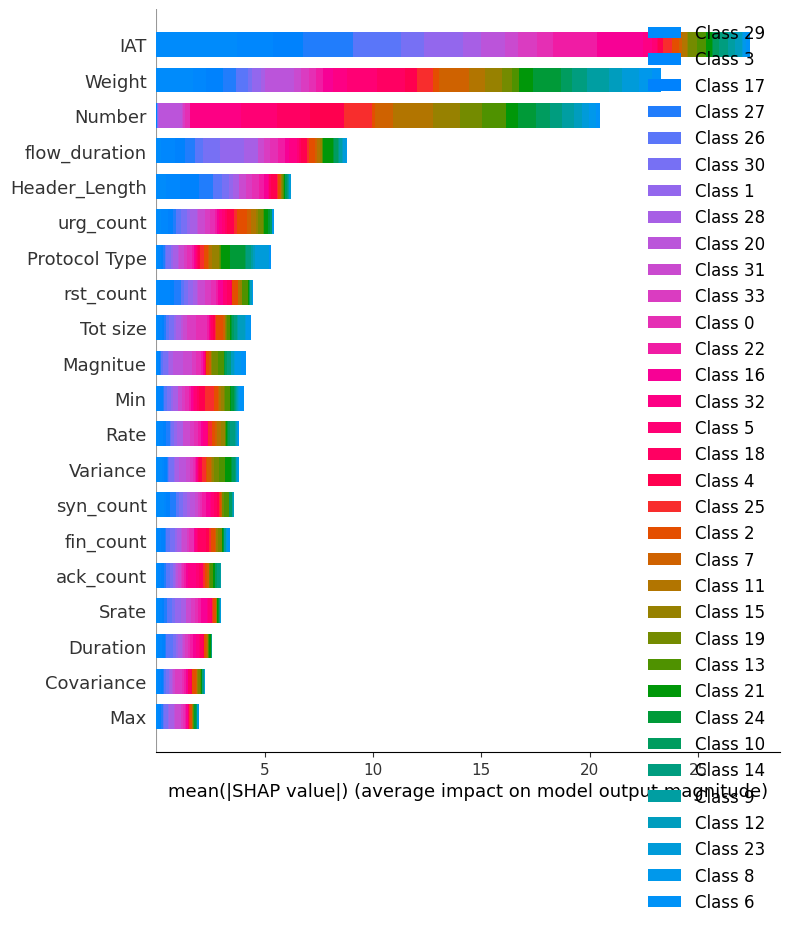

In [11]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

## 4. Individual prediction

### Pick a sample

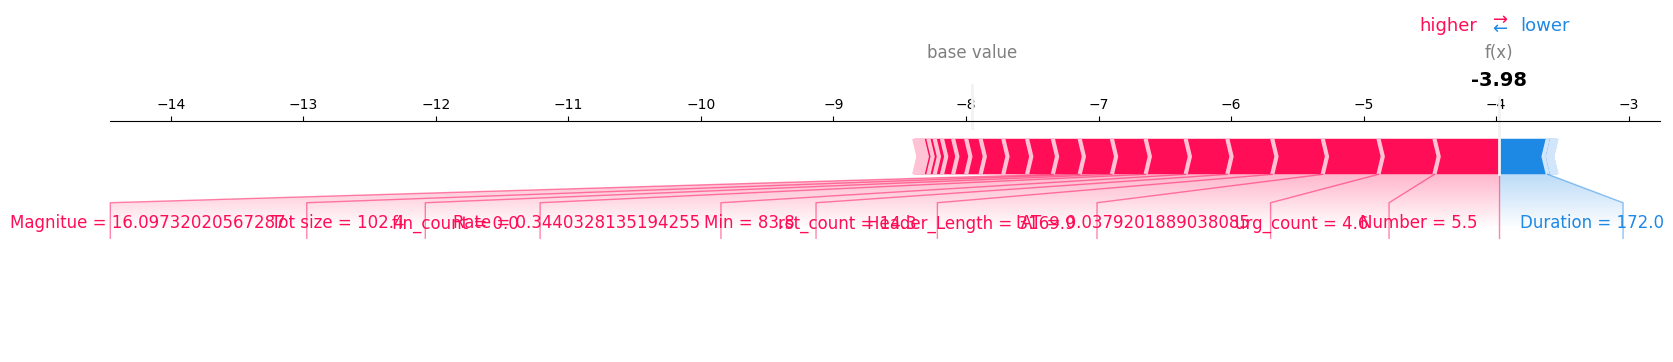

In [12]:
idx = 0  # sample index
class_idx = 0  # pick class (change later)

if isinstance(shap_values, list):
    sv = shap_values[class_idx][idx]
    base = explainer.expected_value[class_idx]
else:
    sv = shap_values[idx, :, class_idx]
    base = explainer.expected_value[class_idx]

shap.force_plot(
    base,
    sv,
    X_sample.iloc[idx],
    matplotlib=True
)

### Waterfall plot

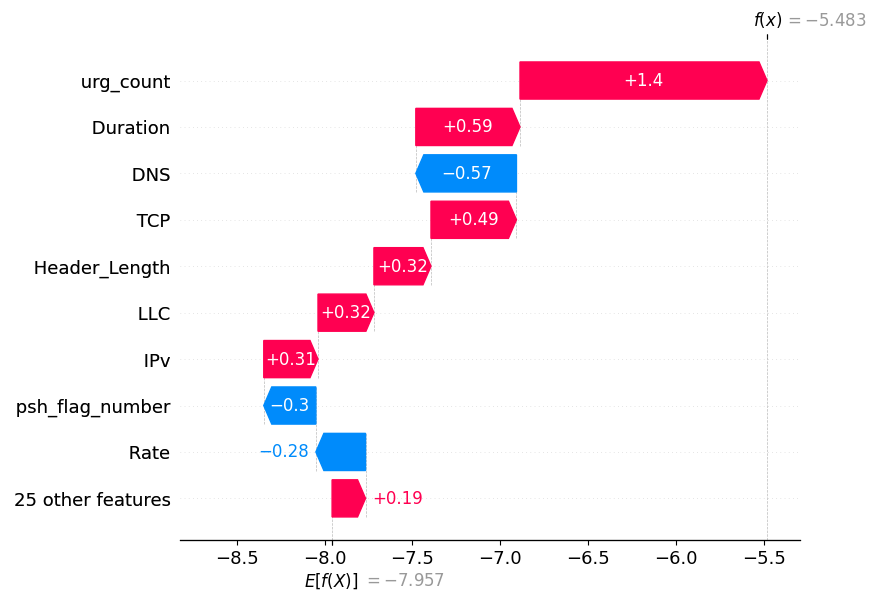

In [13]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],
    shap_values[0][idx],
    X_sample.iloc[idx]
)

## 5. Correct vs Wrong Prediction

In [14]:
y_sample = y_test[X_sample.index]

In [15]:
y_pred = np.argmax(model.predict(X_sample), axis=1)

correct_indices = np.where(y_pred == y_sample)[0]
wrong_indices   = np.where(y_pred != y_sample)[0]

correct_idx = correct_indices[0] if len(correct_indices) > 0 else None
wrong_idx   = wrong_indices[0] if len(wrong_indices) > 0 else None

print("Correct index:", correct_idx)
print("Wrong index:", wrong_idx)

Correct index: 1
Wrong index: 0


In [16]:
print("Total samples:", len(X_sample))
print("Correct predictions:", len(correct_indices))
print("Wrong predictions:", len(wrong_indices))

Total samples: 1000
Correct predictions: 470
Wrong predictions: 530


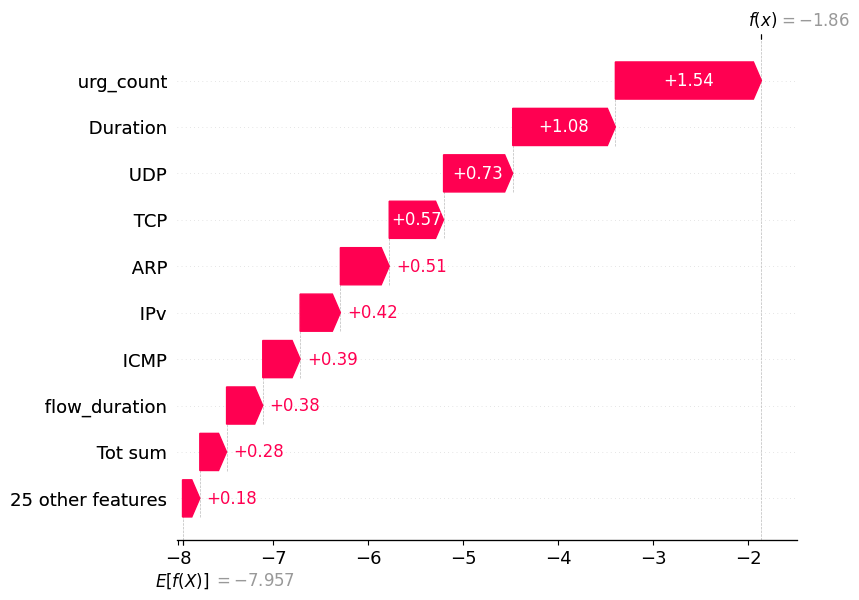

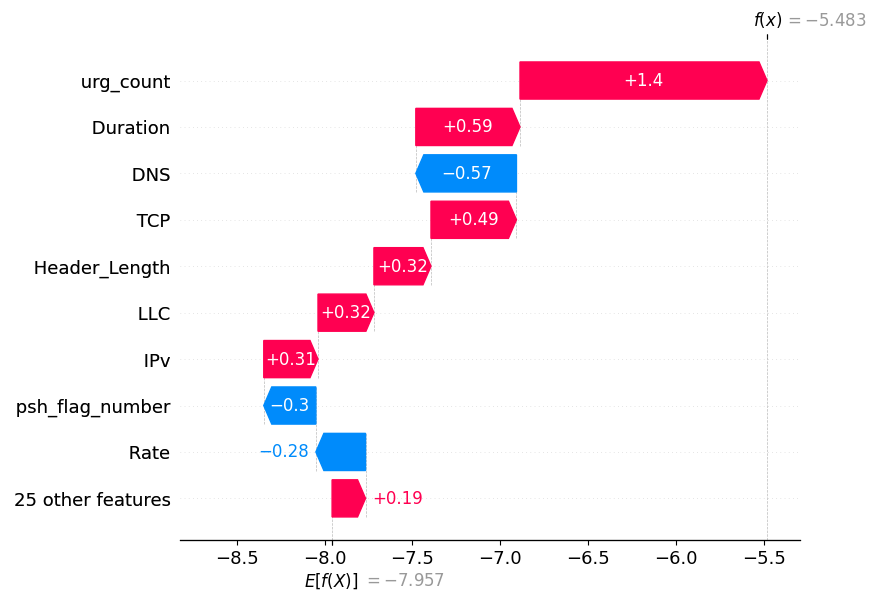

In [17]:
# Correct prediction
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],
    shap_values[0][correct_idx],
    X_sample.iloc[correct_idx]
)

# Wrong prediction
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],
    shap_values[0][wrong_idx],
    X_sample.iloc[wrong_idx]
)